# Importing and Code Cleaning

In [194]:
# Import the JSON file with the data
import json
import pandas as pd

# Read the file
fin = open("data.json", "r")
s = fin.read()
fin.close()

# Store the data using loads
data = json.loads(s)

In [195]:
# Lists to store Dataframe Column information
names = []          # Car Names
dos =   []          # Car Date of Sales
year =  []          # Car Year of Manufacturing
price = []          # Price of car
mileage = []        # Car Mileage
fuel = []           # Car Fuel Type
transmission = []   # Car Transmission Type
body = []           # Car Body Type
sale_loc = []       # County of Sale
description = []    # Car Description
brand_list = []     # Car Brand

# Start by iterating through each brand in the dataset
for brand in data.keys():
    # For each brand, iterate through each specific car
    for car in data[brand]:
        # Append data to lists
        names.append(car.get("name"))
        dos.append(car.get("Date of Sale"))
        brand_list.append(brand)
        year.append(car.get("Year"))
        price.append(car.get("Sale Price"))
        mileage.append(car.get("Mileage"))
        fuel.append(car.get("Fuel Type"))
        transmission.append(car.get("Transmission"))
        body.append(car.get("Body Type"))
        sale_loc.append(car.get("Sale Location"))
        description.append(car.get("Description"))
        
# Create dictionary from lists, storing data of each car        
d = {"Name": names, "Date of Sale": dos, "Year": year, 
     "Price": price, "Mileage": mileage, "Fuel Type": fuel, 
     "Transmission Type": transmission, "Body": body, "Sale Location": sale_loc, "Description": description, "Brand": brand_list}
        

# Create Pandas dataframe from dictionary
df = pd.DataFrame(d)
df


,Name,Date of Sale,Year,Price,Mileage,Fuel Type,Transmission Type,Body,Sale Location,Description,Brand
0,BMW 1 Series (116d),2025-01-02,2019,"€ 9,445.00","66,239 km",diesel,Automatic,Hatchback,Kerry,Grey BMW 1 Series. 1.5 116d SE Auto Euro 6 (s...,BMW
1,BMW 3 Series (SE Business Edition),02/01/2025,2012,"€ 6,495.00","166,517",Diesel,automatic,Estate,Galway,Silver BMW 3 Series. 2.0 320d SE Business Edi...,BMW
2,BMW X1 (SE),2025-01-03,2019,"€15,429.00","70,121",Diesel,Manual,SUV,Donegal,BMW X1. xDrive 18d SE 5dr Diesel Estate 2.0,BMW
3,BMW 8 Series (840d),05/01/2025,2022,"€ 58,023.00","16,906 km",Diesel,Automatic,Convertible,Dublin,Black BMW 8 Series. 840d xDrive Convertible 3...,BMW
4,BMW 4 Series Gran Coupe (420i),2025-01-07,2020,€20962.00,"54,026",petrol,automatic,Hatchback,Dublin,Blue BMW 4 Series Gran Coupe. 420i M Sport Gr...,BMW
...,...,...,...,...,...,...,...,...,...,...,...
1649,Volkswagen T-Roc (TSI EVO),2025-12-17,2022,"€23,379.00",17892,Petrol,manual,SUV,Cork,Green Volkswagen T-Roc. 2017 1.5 TSI SE 150PS...,Volkswagen
1650,Volkswagen Polo (Moda),18/12/2025,2012,"€ 3,802","178,967",Petrol,Manual,Hatchback,Clare,Volkswagen Polo. 1.2 Moda Euro 5 3dr. 4 previ...,Volkswagen
1651,Volkswagen Polo (SE),18/12/2025,2018,"9,743","61,509",Petrol,Manual,Hatchback,Wexford,White Volkswagen Polo. 1.2 SE TSI 3d 89 BHP 2...,Volkswagen
1652,Volkswagen Polo (GTI),21/12/2025,2018,€ 15288.00,"31,171",petrol,Manual,Hatchback,Meath,Red Volkswagen Polo. 1.8 TSI BlueMotion Tech ...,Volkswagen


In [196]:
# Clean Dataset


############### Clean Date Info ###############

# Remove whitespaces from date of sale, store as string
df["Date of Sale"] = df["Date of Sale"].astype(str).str.strip()

# Rewrite all dates in DD-MM-YYYY format
df["Date of Sale"] = pd.to_datetime(df["Date of Sale"], errors='raise', dayfirst=True, format="mixed")

############### Clean Price Info ###############

# Remove EUR or € from all prices, and remove whitespace and commas. Store as floats
df["Price"] = df["Price"].astype(str).str.replace(",", "")
df["Price"] = df["Price"].astype(str).str.replace(" ", "")
df["Price"] = df["Price"].astype(str).str.replace("EUR", "")
df["Price"] = df["Price"].astype(str).str.replace("€", "")
df["Price"] = df["Price"].astype(float)

############### Clean Mileage Info ###############

# Remove whitespace, km and kms from mileage. Store as type float
df["Mileage"] = df["Mileage"].astype(str)
df["Mileage"] = df["Mileage"].str.replace(",", "")
df["Mileage"] = df["Mileage"].str.replace(" ", "")
df["Mileage"] = df["Mileage"].str.replace("kms", "")
df["Mileage"] = df["Mileage"].str.replace("km", "")
df["Mileage"] = df["Mileage"].astype(float)


############### Clean Transmission Info ###############

# Store in lower case, remove whitespace, replace auto with automatic
df["Transmission Type"] = df["Transmission Type"].astype(str).str.lower()
df["Transmission Type"] = df["Transmission Type"].str.replace(" ", "")
df["Transmission Type"] = df["Transmission Type"].str.replace("auto", "automatic")


############### Clean Transmission Info ###############

# Store in lower case, remove whitespace
df["Fuel Type"] = df["Fuel Type"].astype(str).str.lower()
df["Fuel Type"] = df["Fuel Type"].astype(str).str.replace(" ", "")

# If it contains "diesel" and "hybrid", change to "diesel-hybrid", if contains "petrol" and hybrid, change to "petrol-hybrid"
df.loc[df["Fuel Type"].str.contains("diesel") & df["Fuel Type"].str.contains("hybrid"), "Fuel Type"] = "diesel-hybrid"
df.loc[df["Fuel Type"].str.contains("petrol") & df["Fuel Type"].str.contains("hybrid"), "Fuel Type"] = "petrol-hybrid"

############### Clean Year Info ###############

# Store year as ints
df["Year"] = df["Year"].astype(int)


############### Clean Sale Location Info ###############

# Remove whitespace from sale location
df["Sale Location"] =  df["Sale Location"].str.strip()


############### Add additional columns from Description Info ###############
# Some descriptions contain colour and some have number of previous owners. Add these to the dataset as their own columns

# Adding colour info
colours = ["grey", "red", "black", "blue", "silver", "white", "green"] # List of colours
for colour in colours:
    # For each colours, make a mask of if that colours appears in the description. Then add that colour to the Colour column 
    mask = df["Description"].astype(str).str.lower().str.contains(colour, na=False)
    df.loc[mask, "Colour"] = colour 

# Add previous owner info
def extract_number_of_owners(description):
    # Function to extract the number of previous owners from description string. It always appears before 
    # the word previous if present
    split_desc = description.split(" ") # Split the description by spaces
    if "previous" in split_desc:
        # Return the number before previous if it exists
        previous_index = split_desc.index("previous")
        return(int(split_desc[previous_index -1]))
    else:
        # Otherwise return None
        return None


df["Previous Owners"] = df["Description"].apply(extract_number_of_owners)
df


,Name,Date of Sale,Year,Price,Mileage,Fuel Type,Transmission Type,Body,Sale Location,Description,Brand,Colour,Previous Owners
0,BMW 1 Series (116d),2025-01-02,2019,9445.0,66239.0,diesel,automaticmatic,Hatchback,Kerry,Grey BMW 1 Series. 1.5 116d SE Auto Euro 6 (s...,BMW,grey,3.0
1,BMW 3 Series (SE Business Edition),2025-01-02,2012,6495.0,166517.0,diesel,automaticmatic,Estate,Galway,Silver BMW 3 Series. 2.0 320d SE Business Edi...,BMW,silver,2.0
2,BMW X1 (SE),2025-01-03,2019,15429.0,70121.0,diesel,manual,SUV,Donegal,BMW X1. xDrive 18d SE 5dr Diesel Estate 2.0,BMW,NaN,NaN
3,BMW 8 Series (840d),2025-01-05,2022,58023.0,16906.0,diesel,automaticmatic,Convertible,Dublin,Black BMW 8 Series. 840d xDrive Convertible 3...,BMW,black,2.0
4,BMW 4 Series Gran Coupe (420i),2025-01-07,2020,20962.0,54026.0,petrol,automaticmatic,Hatchback,Dublin,Blue BMW 4 Series Gran Coupe. 420i M Sport Gr...,BMW,blue,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,Volkswagen T-Roc (TSI EVO),2025-12-17,2022,23379.0,17892.0,petrol,manual,SUV,Cork,Green Volkswagen T-Roc. 2017 1.5 TSI SE 150PS...,Volkswagen,green,1.0
1650,Volkswagen Polo (Moda),2025-12-18,2012,3802.0,178967.0,petrol,manual,Hatchback,Clare,Volkswagen Polo. 1.2 Moda Euro 5 3dr. 4 previ...,Volkswagen,NaN,4.0
1651,Volkswagen Polo (SE),2025-12-18,2018,9743.0,61509.0,petrol,manual,Hatchback,Wexford,White Volkswagen Polo. 1.2 SE TSI 3d 89 BHP 2...,Volkswagen,white,2.0
1652,Volkswagen Polo (GTI),2025-12-21,2018,15288.0,31171.0,petrol,manual,Hatchback,Meath,Red Volkswagen Polo. 1.8 TSI BlueMotion Tech ...,Volkswagen,blue,2.0


In [197]:
#print any missing values
print(df.isnull().sum())

Name                   0
Date of Sale           0
Year                   0
Price                  0
Mileage                0
Fuel Type              0
Transmission Type      0
Body                   0
Sale Location          0
Description            0
Brand                  0
Colour               210
Previous Owners      686
dtype: int64


In [198]:
# value_counts was performed on each column to make sure that there was no unexpected data
df["Body"].value_counts()

Body
Hatchback      469
SUV            384
Saloon         368
Coupe          167
Estate         136
Convertible    104
S.U.V.          20
Estat            6
Name: count, dtype: int64

# Analysis

## Geographical Plots

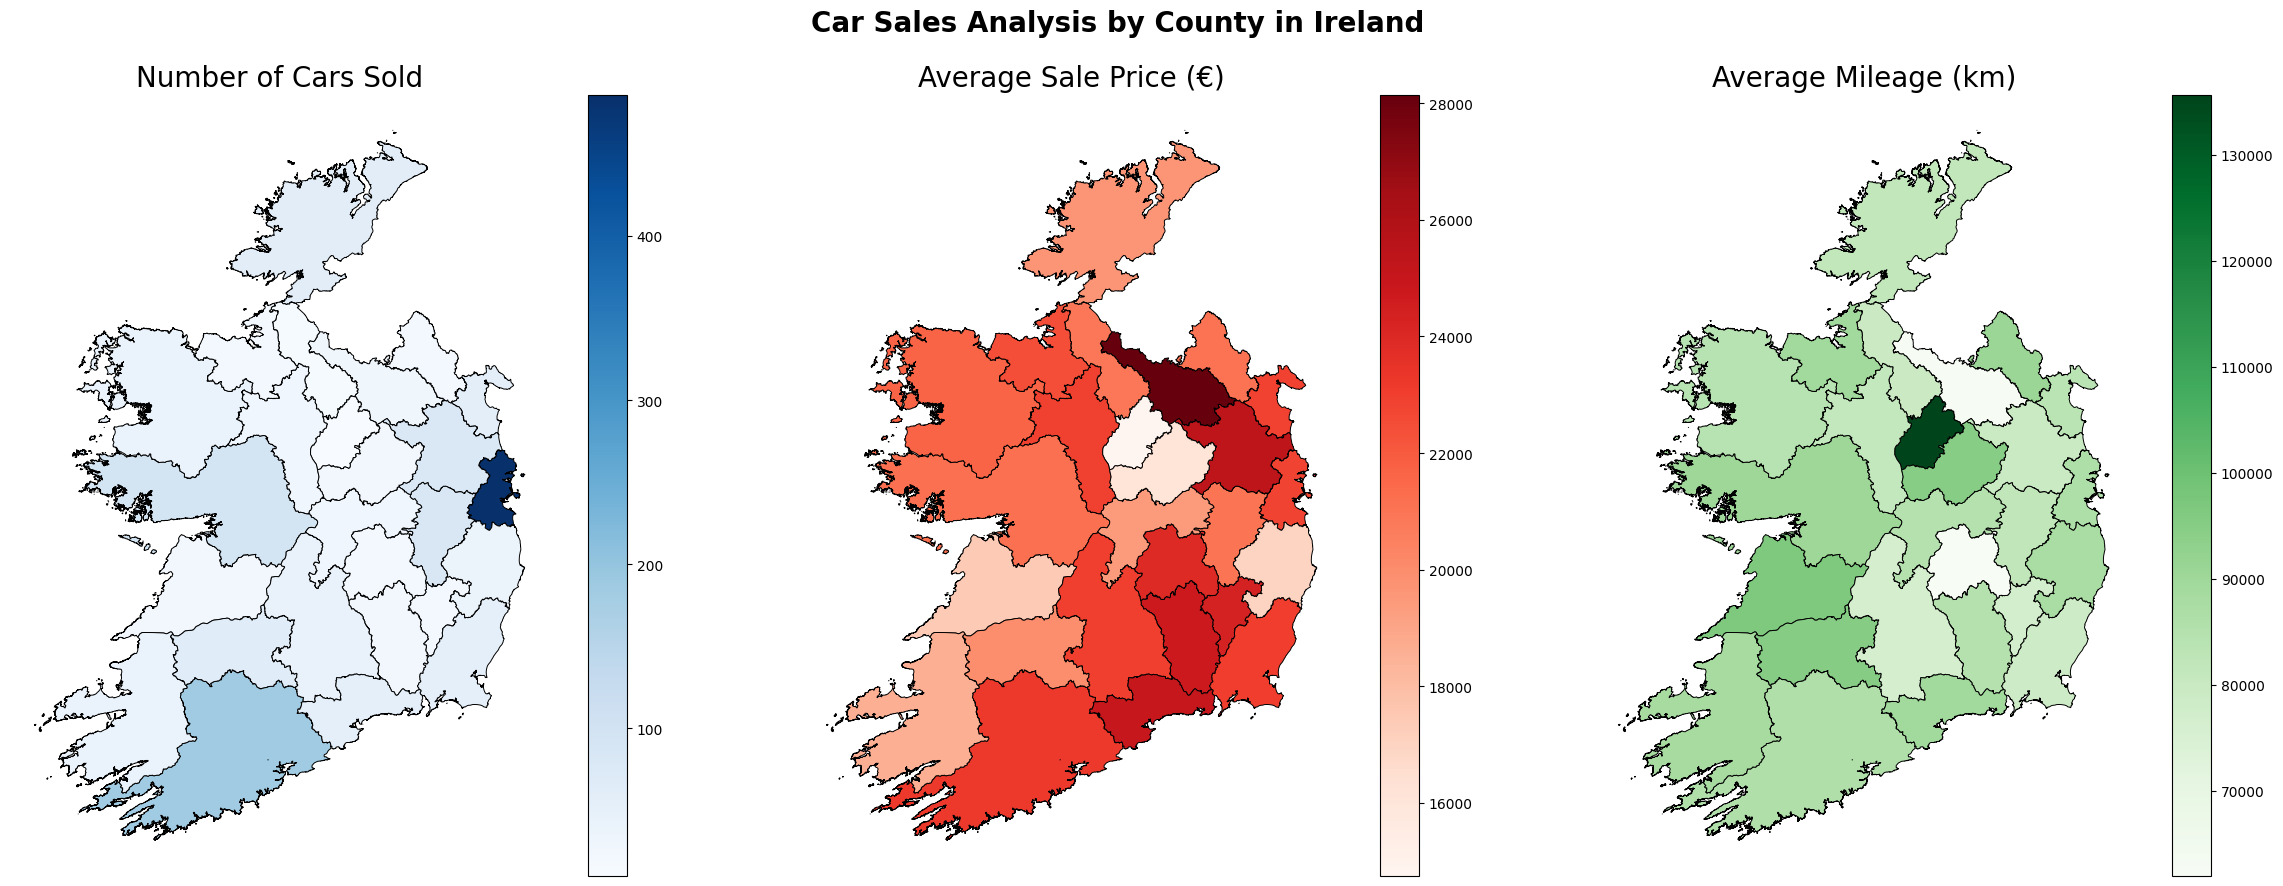

In [199]:
# Maps of Ireland Plots using Geopandas
import geopandas as gpd
import matplotlib.pyplot as plt

# Read GeoJSON file, stores boundary information for irish counties. This ireland class acts as a new dataframe
ireland = gpd.read_file("ireland-counties.geojson")

# Have to map undefined regions (i.e., Limerick City to Limerick) and remove "County" from everything
name_map = {
    "Limerick City": "Limerick",
    "Limerick County": "Limerick",
    "North Tipperary": "Tipperary",
    "South Tipperary": "Tipperary",
    "Waterford City": "Waterford",
    "Waterford County": "Waterford",
    "Galway City": "Galway",
    "Galway County": "Galway",
    "Dublin City": "Dublin",
    "South Dublin": "Dublin",
    "Fingal": "Dublin",
    "Dún Laoghaire-Rathdown": "Dublin",
    "Cork City": "Cork",
    "Cork County": "Cork",
}

def map_to_pandas_county_format(geopandas_name):
    # This function maps the geopandas county name to the name used in the dataset (i.e., County Clare just becomes Clare)
    county = name_map.get(geopandas_name, None) # If the name is in the name map, use it
    if county == None:
        # Otherwise, just remove "County" from it
        return geopandas_name.replace("County", "").strip()
    return county
    
# Add the sale location to the geopandas dataframe using the map_to_pandas_county_format() function
ireland["Sale Location"] = ireland["name"].map(map_to_pandas_county_format)
ireland = ireland.dissolve(by="Sale Location").reset_index() # Because both "Limerick City" and "Limerick County" become Limerick, they need to be combined

# Next, add the mileage price, and number of car sales to the ireland dataframe
# Make a dataframe of just the average mileage, average price, and number of car sales per county
avg_prices = df.groupby("Sale Location")["Price"].mean()
avg_mileage = df.groupby("Sale Location")["Mileage"].mean()
count = df["Sale Location"].value_counts()

# Merge the Dataframes, using inner merge
ireland = ireland.merge(avg_prices, on="Sale Location", how="inner")
ireland = ireland.merge(avg_mileage, on="Sale Location", how="inner")
ireland = ireland.merge(count, on="Sale Location", how="inner")

# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Car Sales Analysis by County in Ireland', fontsize=20, fontweight='bold', y=0.98)

# Plot the number of sales per county
ireland.plot(
    column="count",
    ax=axes[0],
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.7
 )
axes[0].set_title('Number of Cars Sold', fontsize=20)
axes[0].axis('off')

# Plot the average price per county
ireland.plot(
    column="Price",
    ax=axes[1],
    cmap="Reds",
    legend=True,
    edgecolor="black",
    linewidth=0.7
 )
axes[1].set_title('Average Sale Price (€)', fontsize=20)
axes[1].axis('off')

# Plot the average mileage per county
ireland.plot(
    column="Mileage",
    ax=axes[2],
    cmap="Greens",
    legend=True,
    edgecolor="black",
    linewidth=0.7
 )
axes[2].set_title('Average Mileage (km)', fontsize=20)
axes[2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])

### Discussion 

## Fuel Type Plot

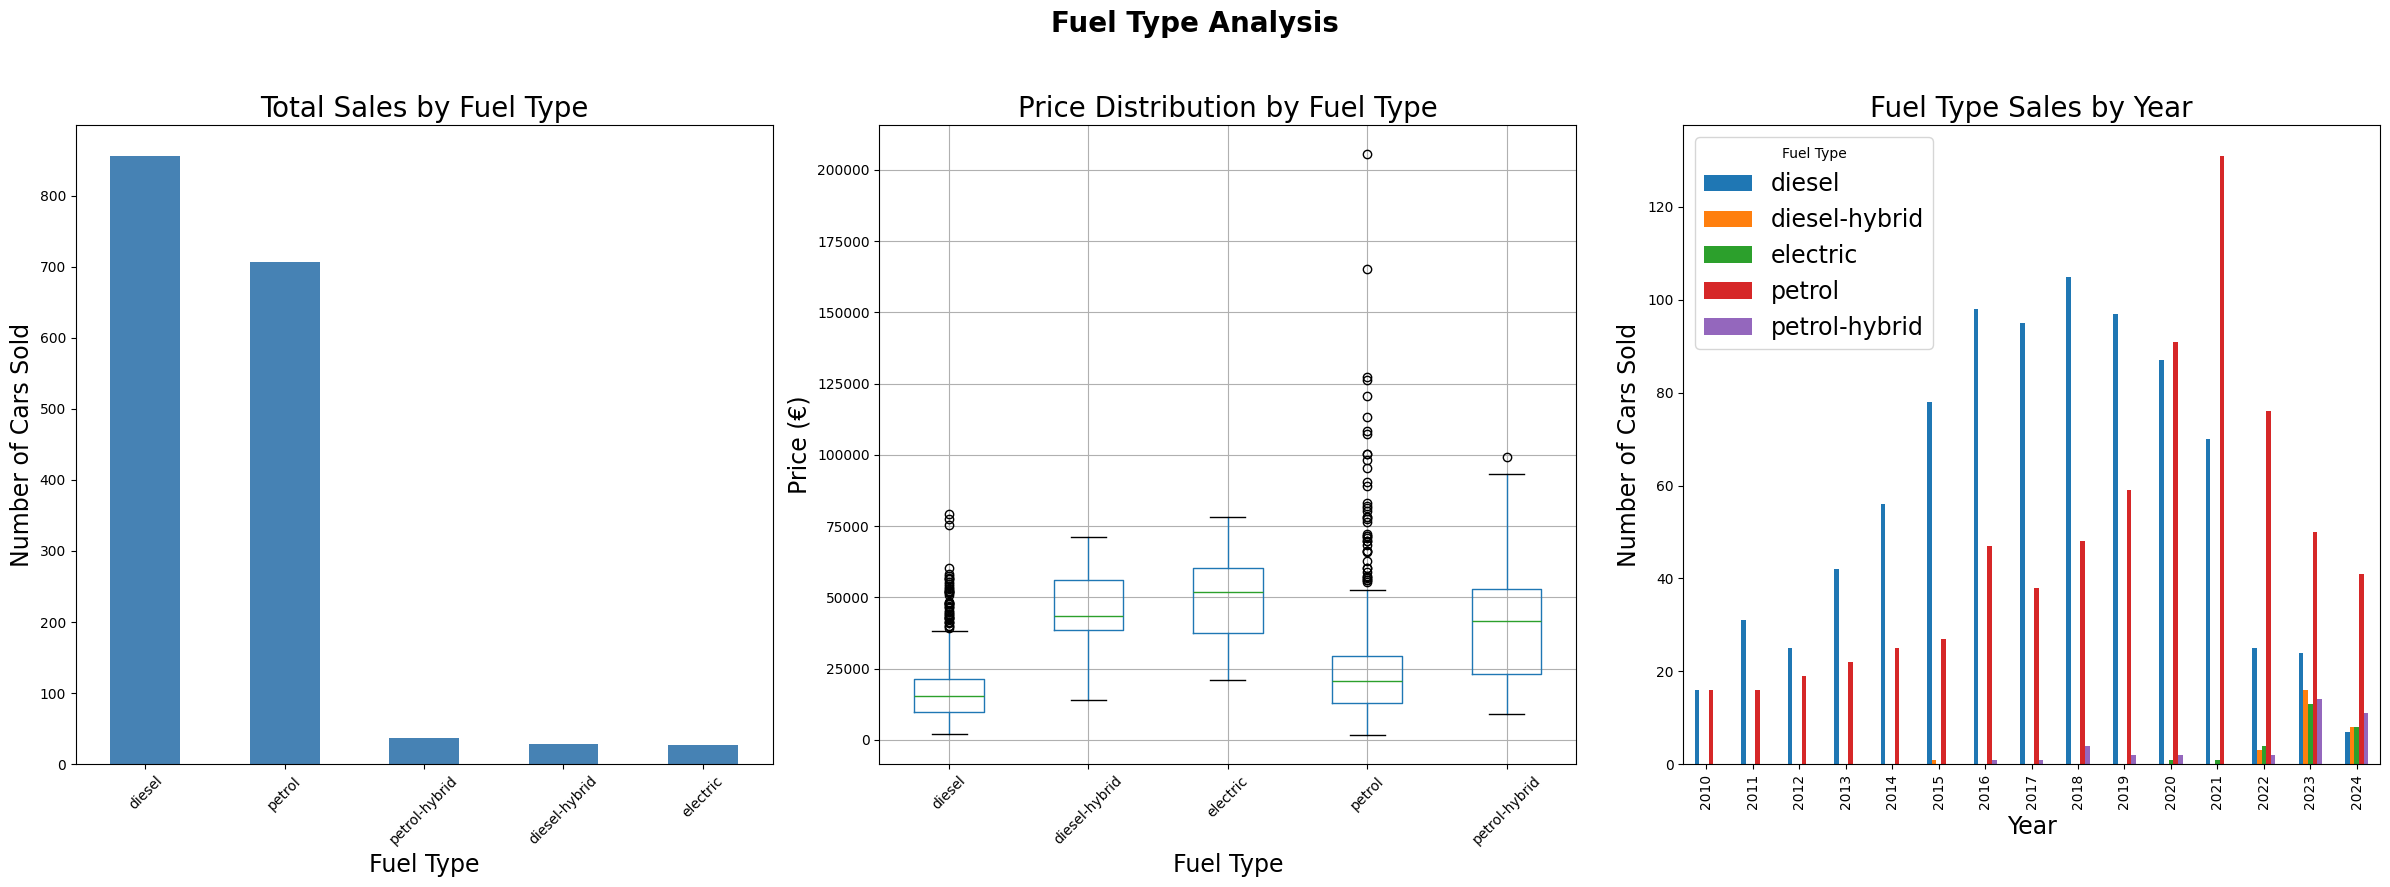

In [200]:
# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Fuel Type Analysis', fontsize=20, fontweight='bold', y=0.98)

# Plot the total number of each Fuel type sold
df["Fuel Type"].value_counts().plot(kind="bar", ax = axes[0], color='steelblue')
axes[0].set_title('Total Sales by Fuel Type', fontsize=20)
axes[0].set_xlabel('Fuel Type', fontsize=17)
axes[0].set_ylabel('Number of Cars Sold', fontsize=17)
axes[0].tick_params(axis='x', rotation=45)

# Compare the price of different fuel types
df.boxplot(column="Price",
           by="Fuel Type",
           ax = axes[1])
axes[1].set_title('Price Distribution by Fuel Type', fontsize=20)
axes[1].set_xlabel('Fuel Type', fontsize=17)
axes[1].set_ylabel('Price (€)', fontsize=17)
plt.sca(axes[1])
plt.xticks(rotation=45)
fig.canvas.draw()
fig.suptitle('Fuel Type Analysis', fontsize=20, fontweight='bold', y=0.98)

# Compare the number of each fuel type sold per year
# Using unstack here changes it from a dataframe with year, fuel type and count as the columns to 
# one with year, diesel, petrol etc. as the columns with the counts as the entries
df.groupby("Year")["Fuel Type"].value_counts().unstack().plot(kind="bar", ax= axes[2])
axes[2].set_title('Fuel Type Sales by Year', fontsize=20)
axes[2].set_xlabel('Year', fontsize=17)
axes[2].set_ylabel('Number of Cars Sold', fontsize=17)
axes[2].legend(title='Fuel Type' , fontsize=17)

plt.tight_layout(rect=[0, 0, 1, 0.95])

### Discussion

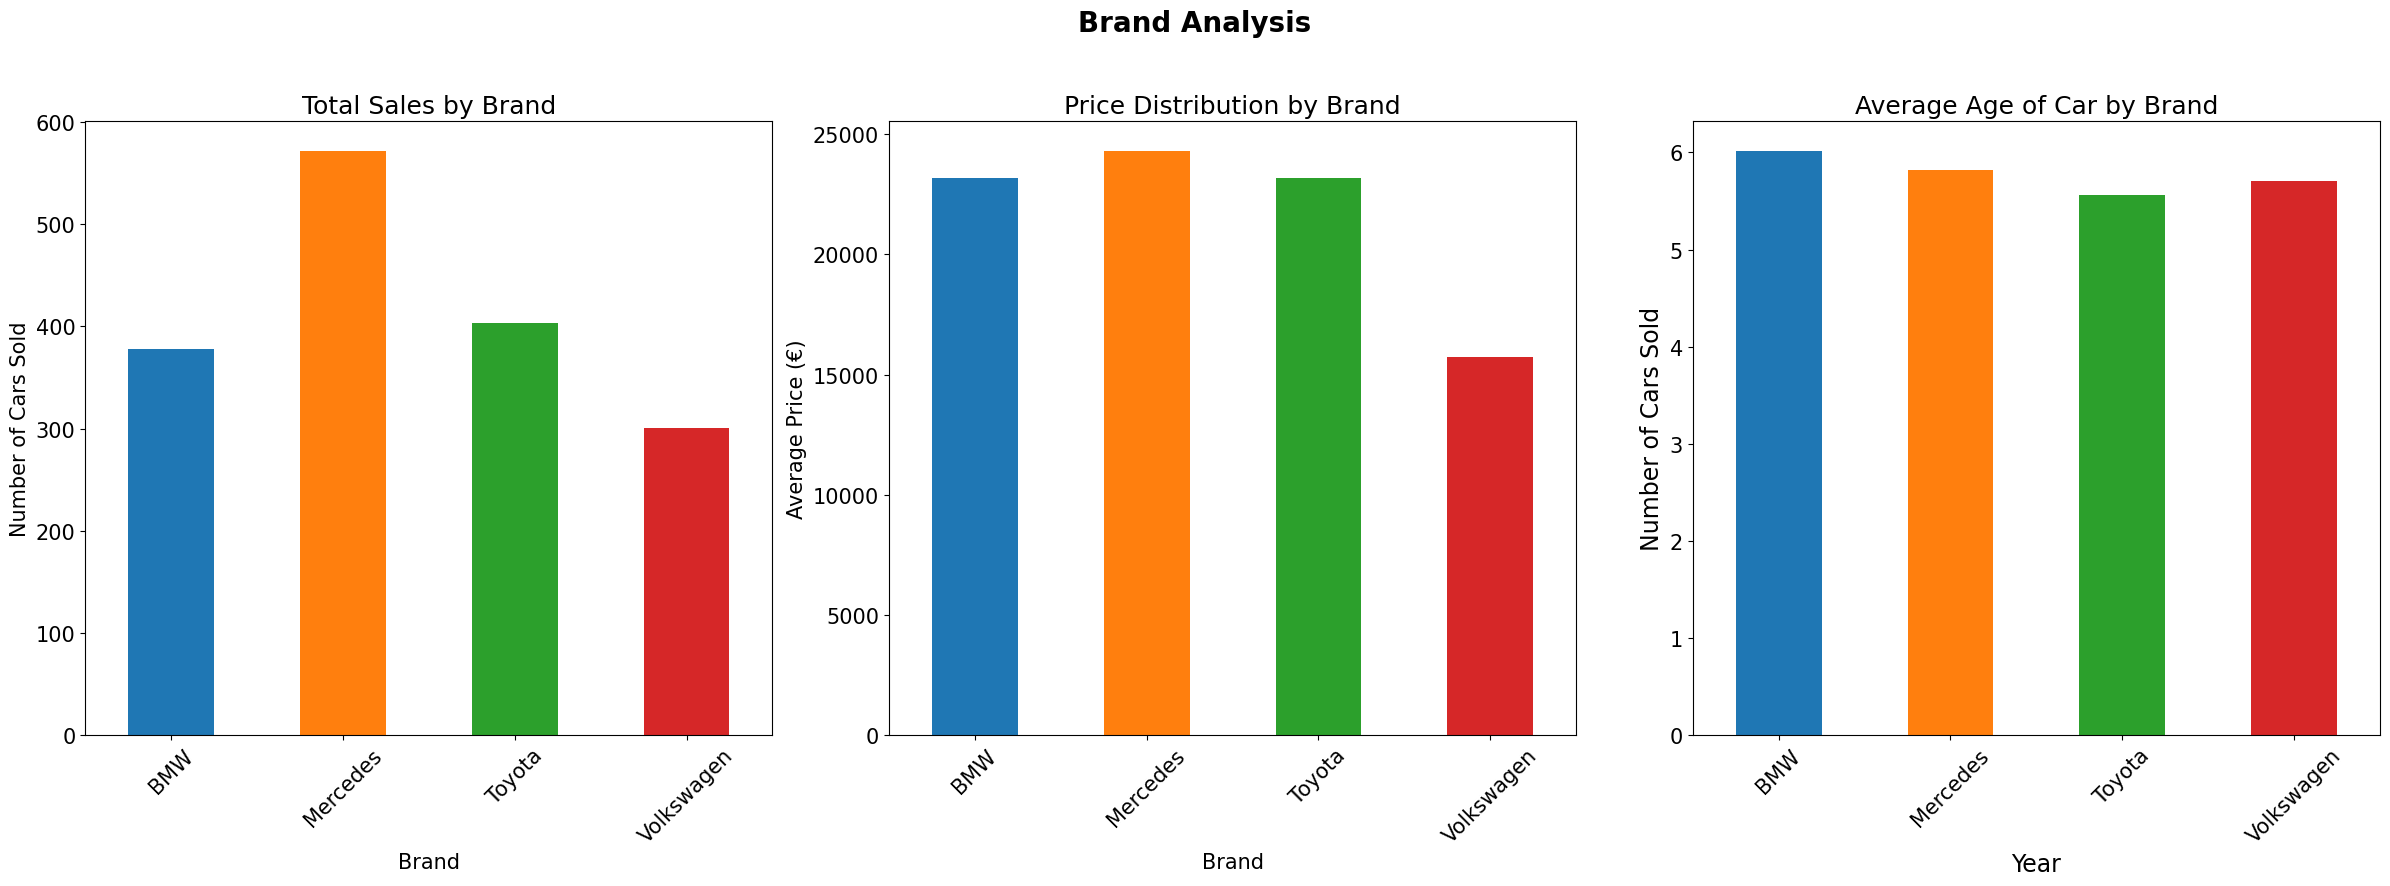

In [ ]:
# Brand analysis
# three plots. 1. number of each car brand sold, 2. Price of each brand, 3. Avg. age per brand

# Set brand colours across all graphs
brand_colours = {
    'BMW': '#1f77b4',
    'Mercedes': '#ff7f0e',
    'Toyota': '#2ca02c',     
    'Volkswagen': '#d62728'  
}

# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))


# Get brand value counts and map colours to match the order
brand_counts = df["Brand"].value_counts().sort_index()
colours_for_bars = [brand_colours[brand] for brand in brand_counts.index]
brand_counts.plot(kind="bar", ax = axes[0], color=colours_for_bars)
axes[0].set_title('Total Sales by Brand', fontsize=18)
axes[0].set_xlabel('Brand', fontsize=15)
axes[0].set_ylabel('Number of Cars Sold', fontsize=15)
axes[0].tick_params(axis='x', rotation=45, labelsize=15)
axes[0].tick_params(axis='y', labelsize=15)

# Plot the average price per car brand
avg_prices_by_brand = df.groupby("Brand")["Price"].mean()
colours_for_price_bars = [brand_colours[brand] for brand in avg_prices_by_brand.index]
avg_prices_by_brand.plot(kind="bar", ax=axes[1], color=colours_for_price_bars)
axes[1].set_title('Price Distribution by Brand', fontsize=18)
axes[1].set_xlabel('Brand', fontsize=15)
axes[1].set_ylabel('Average Price (€)', fontsize=15)
axes[1].tick_params(axis='x', rotation=45, labelsize=15)
axes[1].tick_params(axis='y', labelsize=15)

df["Age"] = df["Year"].max() -  df["Year"]

avg_prices_by_brand = df.groupby("Brand")["Age"].mean()
colours_for_price_bars = [brand_colours[brand] for brand in avg_prices_by_brand.index]
avg_prices_by_brand.plot(kind="bar", ax=axes[2], color=colours_for_price_bars)
axes[2].set_title('Average Age of Car by Brand', fontsize=18)
axes[2].set_xlabel('Year', fontsize=17)
axes[2].set_ylabel('Number of Cars Sold', fontsize=17)
axes[2].tick_params(axis='x', labelsize=15, labelrotation=45)
axes[2].tick_params(axis='y', labelsize=15)

fig.suptitle('Brand Analysis', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])


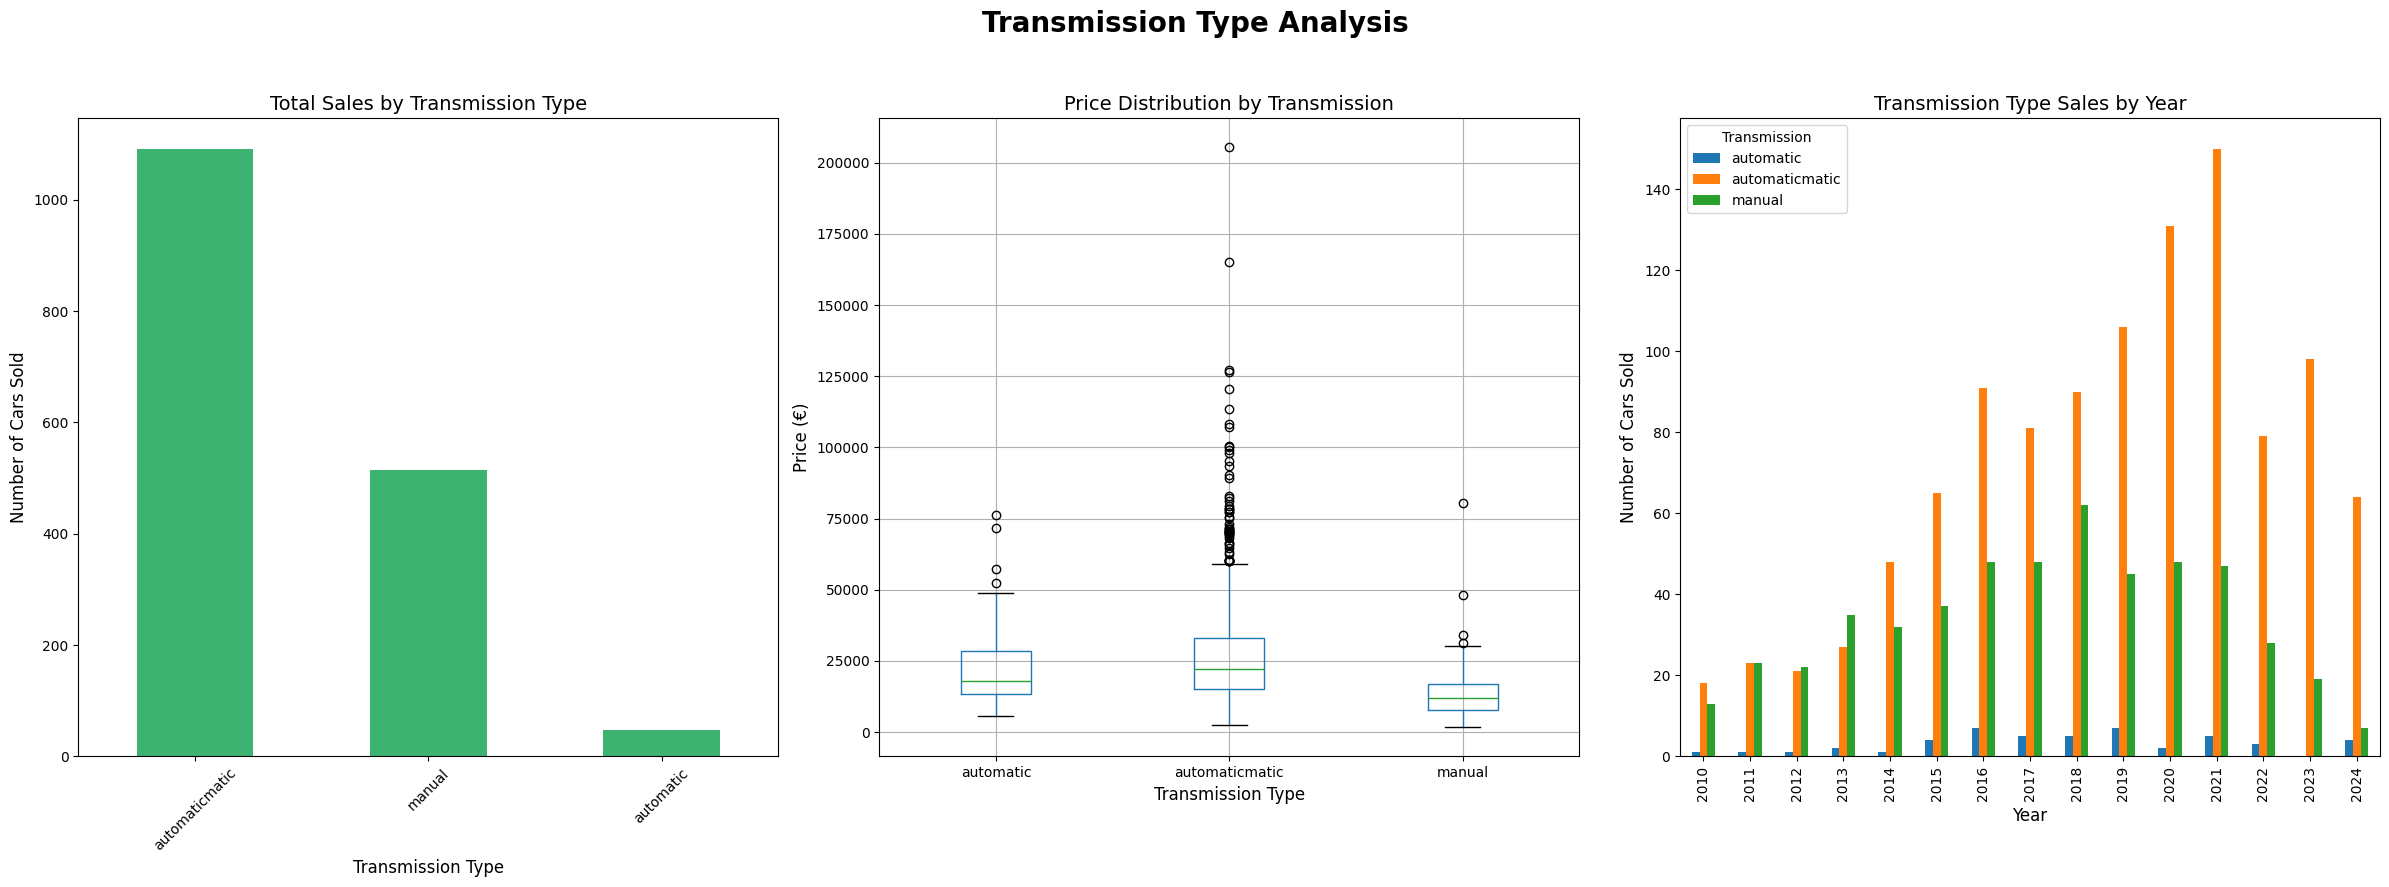

In [202]:
# Do the same for transmission type

# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Transmission Type Analysis', fontsize=20, fontweight='bold', y=0.98)

df["Transmission Type"].value_counts().plot(kind="bar", ax = axes[0], color='mediumseagreen') #TODO verify that this is correct off the number of pages on website
axes[0].set_title('Total Sales by Transmission Type', fontsize=14)
axes[0].set_xlabel('Transmission Type', fontsize=12)
axes[0].set_ylabel('Number of Cars Sold', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

df.boxplot(column="Price",
           by="Transmission Type",
           ax = axes[1])
axes[1].set_title('Price Distribution by Transmission', fontsize=14)
axes[1].set_xlabel('Transmission Type', fontsize=12)
axes[1].set_ylabel('Price (€)', fontsize=12)
fig.canvas.draw()
fig.suptitle('Transmission Type Analysis', fontsize=20, fontweight='bold', y=0.98)

df.groupby("Year")["Transmission Type"].value_counts().unstack().plot(kind="bar", ax= axes[2])
axes[2].set_title('Transmission Type Sales by Year', fontsize=14)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_ylabel('Number of Cars Sold', fontsize=12)
axes[2].legend(title='Transmission', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])

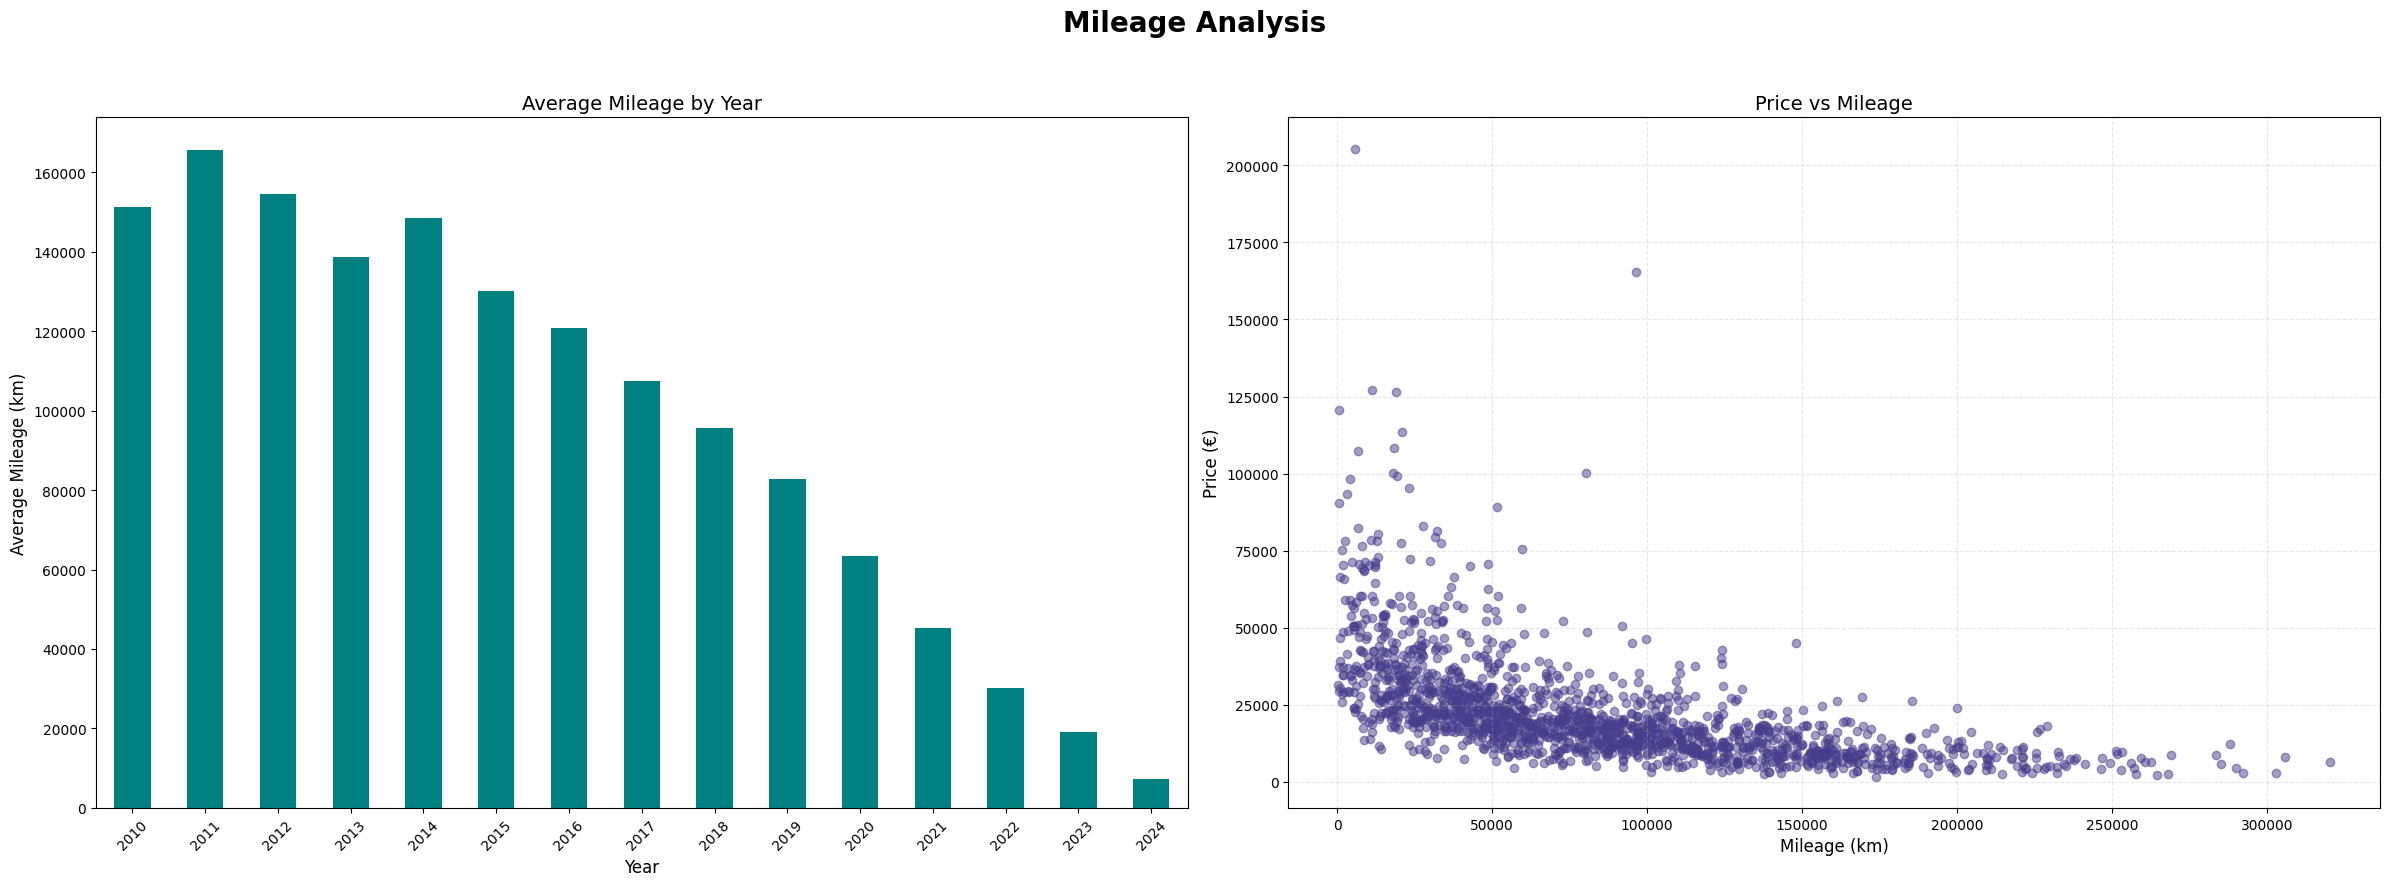

In [203]:
# Mileage plots
# 1. Mileage vs Year. #2. Mileage vs Price

# One figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 9))
fig.suptitle('Mileage Analysis', fontsize=20, fontweight='bold', y=0.98)

df.groupby("Year")["Mileage"].mean().plot(kind="bar", ax=axes[0], color='teal')
axes[0].set_title('Average Mileage by Year', fontsize=14)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Average Mileage (km)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Mileage vs price scatter plot
axes[1].scatter(df["Mileage"], df["Price"], alpha=0.5, color='darkslateblue')
axes[1].set_title('Price vs Mileage', fontsize=14)
axes[1].set_xlabel('Mileage (km)', fontsize=12)
axes[1].set_ylabel('Price (€)', fontsize=12)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout(rect=[0, 0, 1, 0.95])

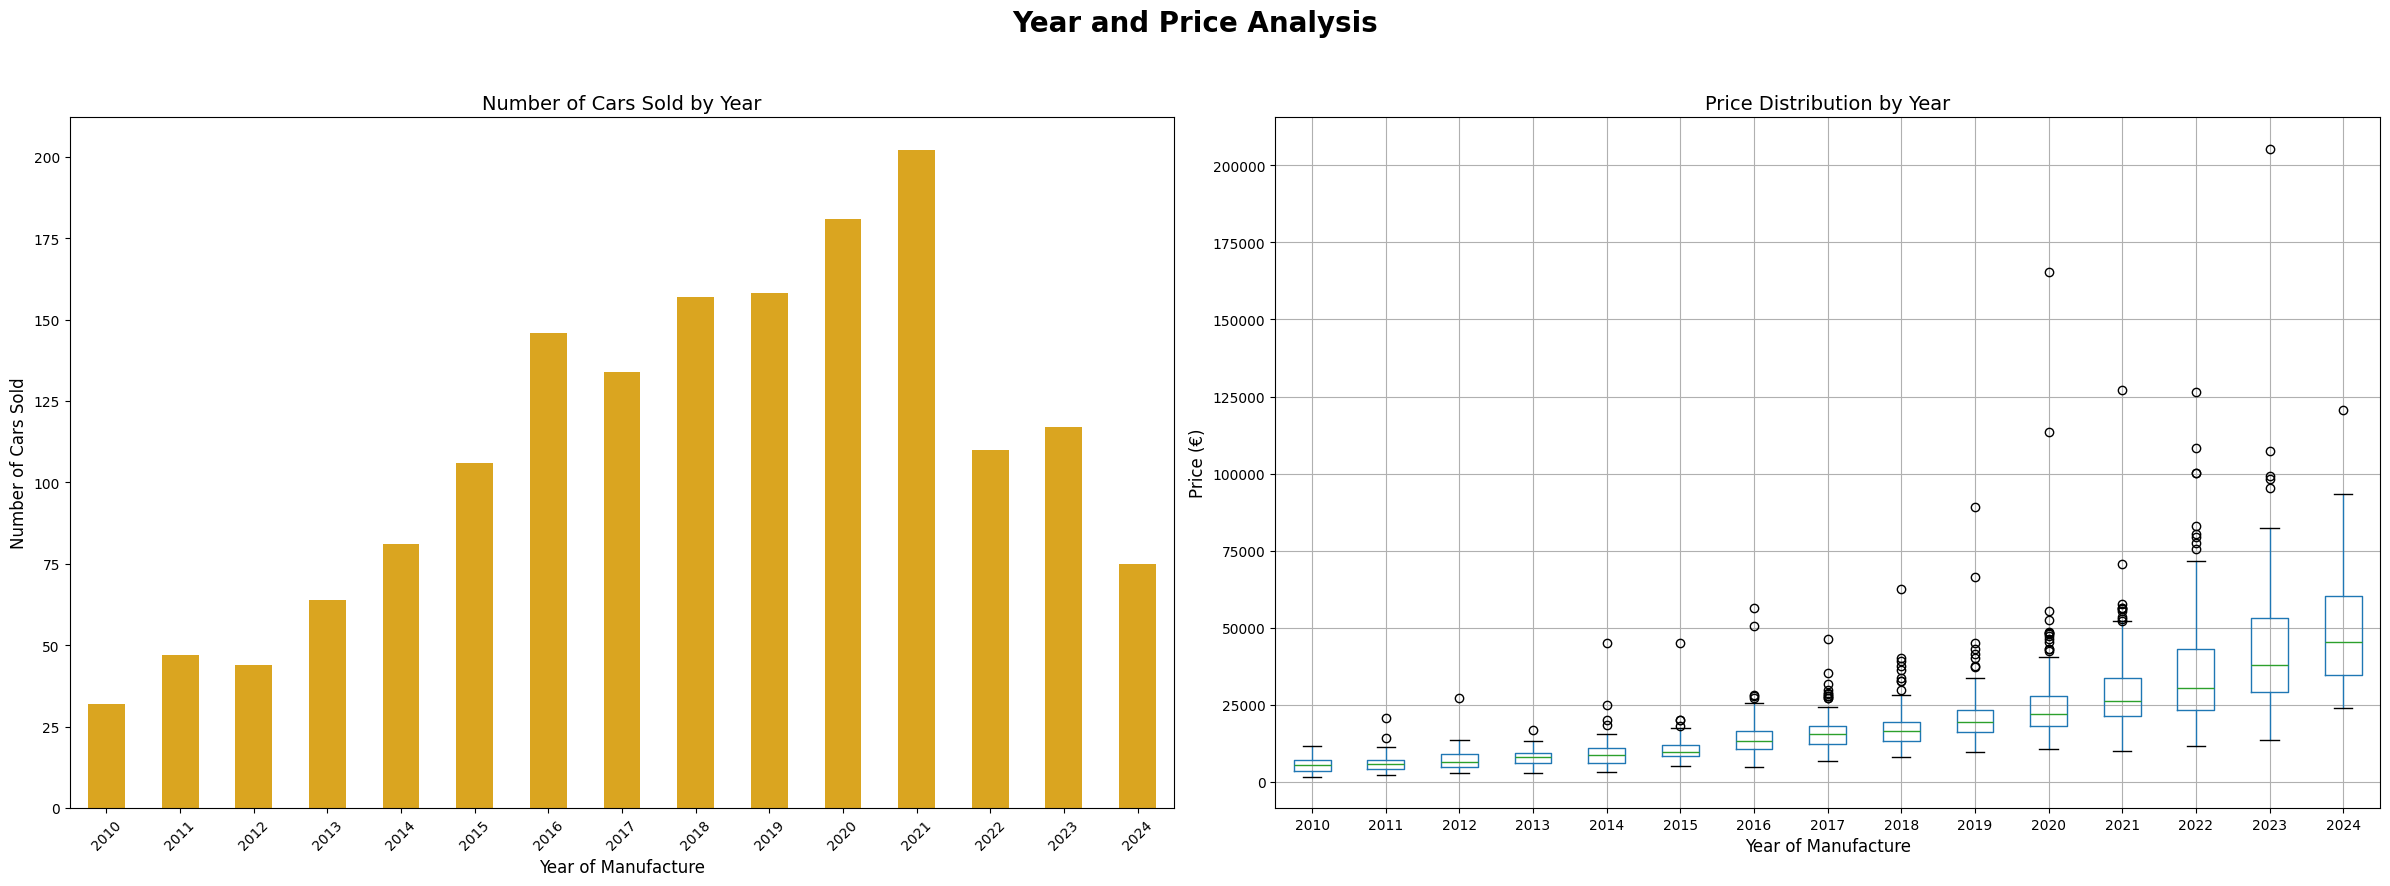

In [204]:
# Prices plots
# 1. Distribution of how old cars are, # 2. Price distribution by year
fig, axes = plt.subplots(1, 2, figsize=(24, 9))
fig.suptitle('Year and Price Analysis', fontsize=20, fontweight='bold', y=0.98)

df["Year"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color='goldenrod')
axes[0].set_title('Number of Cars Sold by Year', fontsize=14)
axes[0].set_xlabel('Year of Manufacture', fontsize=12)
axes[0].set_ylabel('Number of Cars Sold', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Year vs price box plot
df.boxplot(column="Price", by="Year", ax=axes[1])
axes[1].set_title('Price Distribution by Year', fontsize=14)
axes[1].set_xlabel('Year of Manufacture', fontsize=12)
axes[1].set_ylabel('Price (€)', fontsize=12)
fig.canvas.draw()
fig.suptitle('Year and Price Analysis', fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])

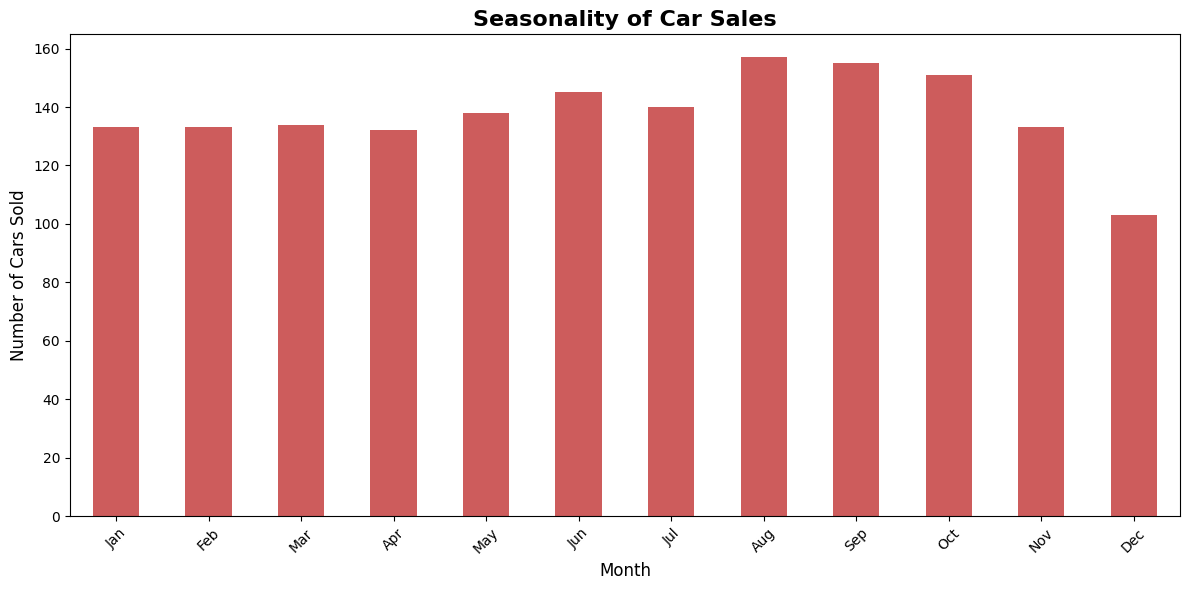

In [205]:
# Are car sales seasonal?
fig, ax = plt.subplots(figsize=(12, 6))
month_counts = df["Date of Sale"].dt.month.value_counts().sort_index()
month_counts.plot(kind="bar", ax=ax, color='indianred')
ax.set_title('Seasonality of Car Sales', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Cars Sold', fontsize=12)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.tight_layout()

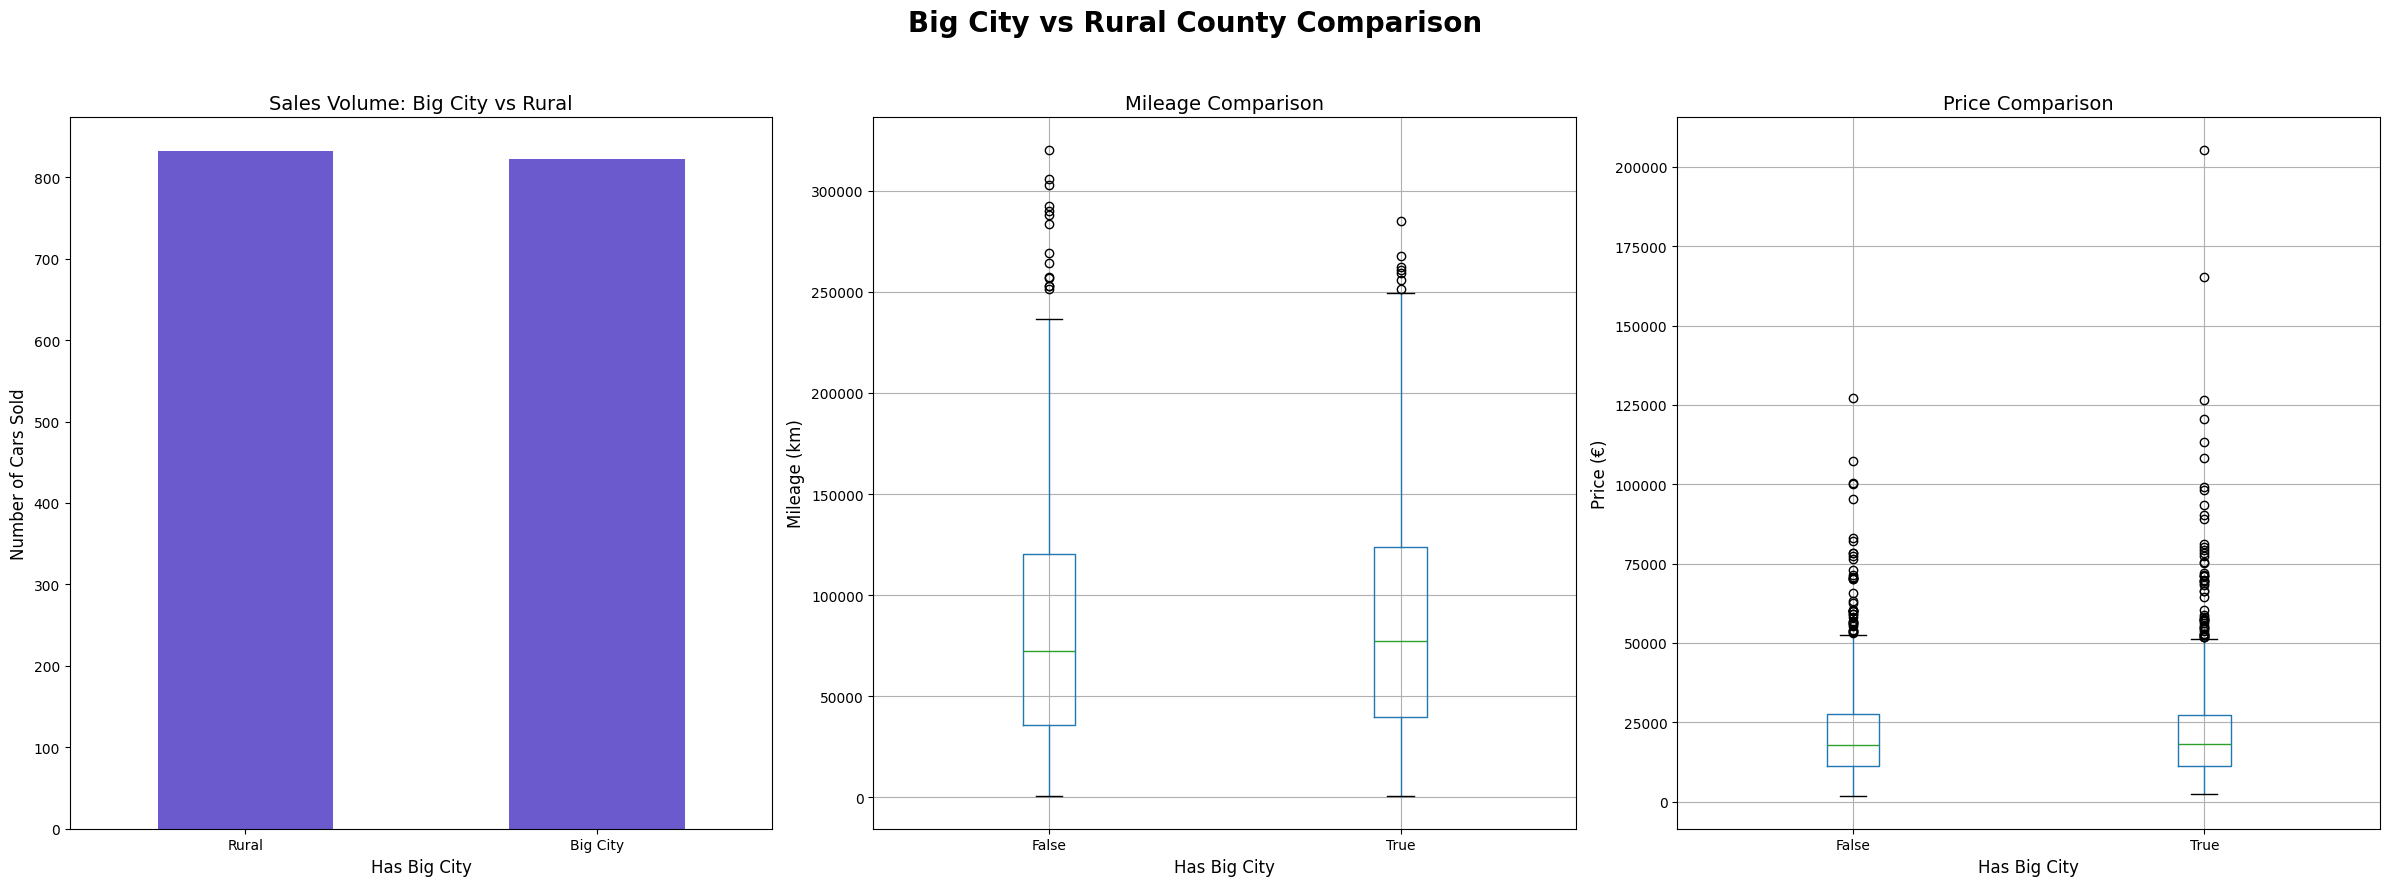

In [206]:
# Compare the mileage in counties with and without big cities
# One figure with 2 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Big City vs Rural County Comparison', fontsize=20, fontweight='bold', y=0.98)

counties_with_big_cities = ["Dublin", "Limerick", "Cork", "Galway"]

df["Has Big City"] = df["Sale Location"].isin(counties_with_big_cities)

# Compare the number of cars sold with and without big cities
df["Has Big City"].value_counts().plot(kind="bar", ax=axes[0], color='slateblue')
axes[0].set_title('Sales Volume: Big City vs Rural', fontsize=14)
axes[0].set_xlabel('Has Big City', fontsize=12)
axes[0].set_ylabel('Number of Cars Sold', fontsize=12)
axes[0].set_xticklabels(['Rural', 'Big City'], rotation=0)

df.boxplot(column="Mileage", by="Has Big City", ax=axes[1])
axes[1].set_title('Mileage Comparison', fontsize=14)
axes[1].set_xlabel('Has Big City', fontsize=12)
axes[1].set_ylabel('Mileage (km)', fontsize=12)

# Compare prices in counties with and without big city
df.boxplot(column="Price", by="Has Big City", ax=axes[2])
axes[2].set_title('Price Comparison', fontsize=14)
axes[2].set_xlabel('Has Big City', fontsize=12)
axes[2].set_ylabel('Price (€)', fontsize=12)
fig.canvas.draw()
fig.suptitle('Big City vs Rural County Comparison', fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])

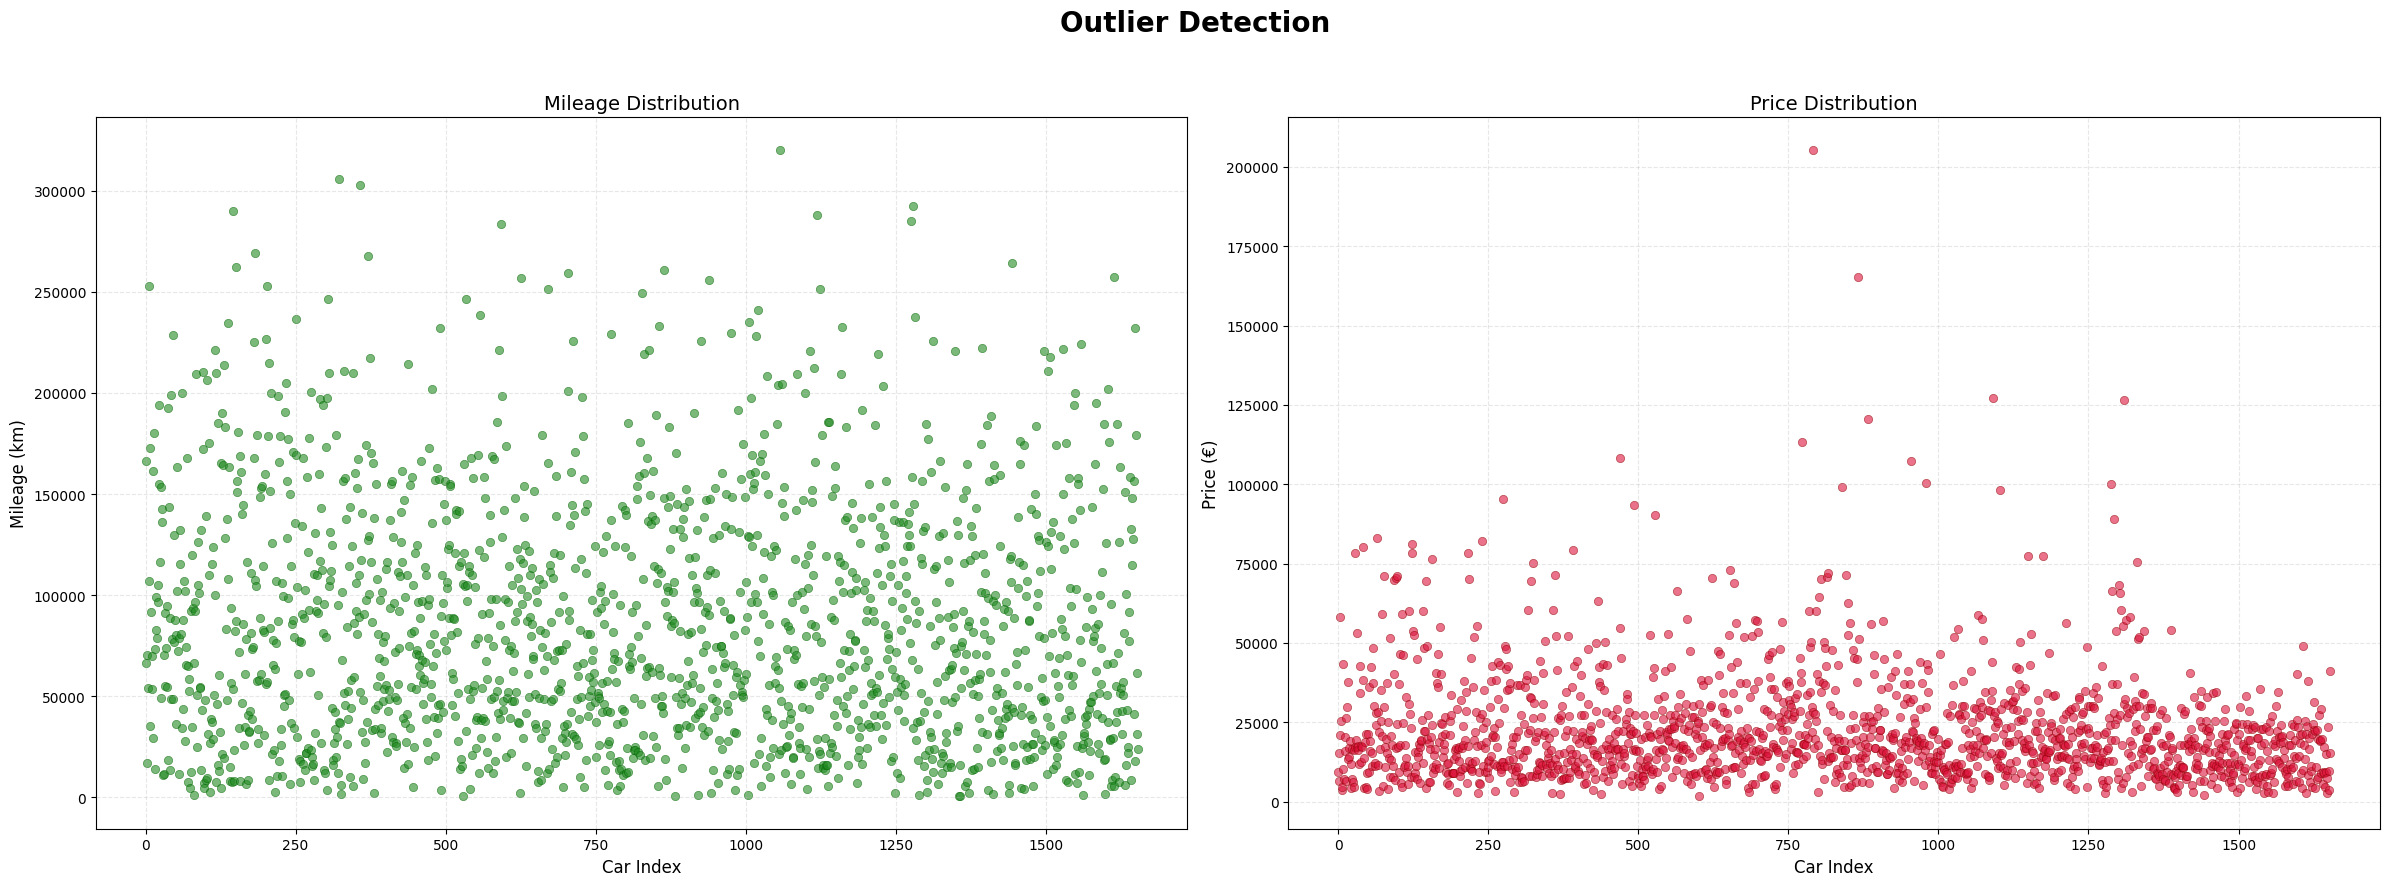

In [ ]:
# Find any statistical outliers in the price and mileage data
# TODO make these boxplots maybe

fig, axes = plt.subplots(1, 2, figsize=(24, 9))
fig.suptitle('Outlier Detection', fontsize=20, fontweight='bold', y=0.98)

axes[0].scatter(df.index, df["Mileage"], alpha=0.6, color='forestgreen', edgecolors='darkgreen', linewidth=0.5)
axes[0].set_xlabel("Car Index", fontsize=12)
axes[0].set_ylabel("Mileage (km)", fontsize=12)
axes[0].set_title("Mileage Distribution", fontsize=14)
axes[0].grid(True, alpha=0.3, linestyle='--')

axes[1].scatter(df.index, df["Price"], alpha=0.6, color='crimson', edgecolors='darkred', linewidth=0.5)
axes[1].set_xlabel("Car Index", fontsize=12)
axes[1].set_ylabel("Price (€)", fontsize=12)
axes[1].set_title("Price Distribution", fontsize=14)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

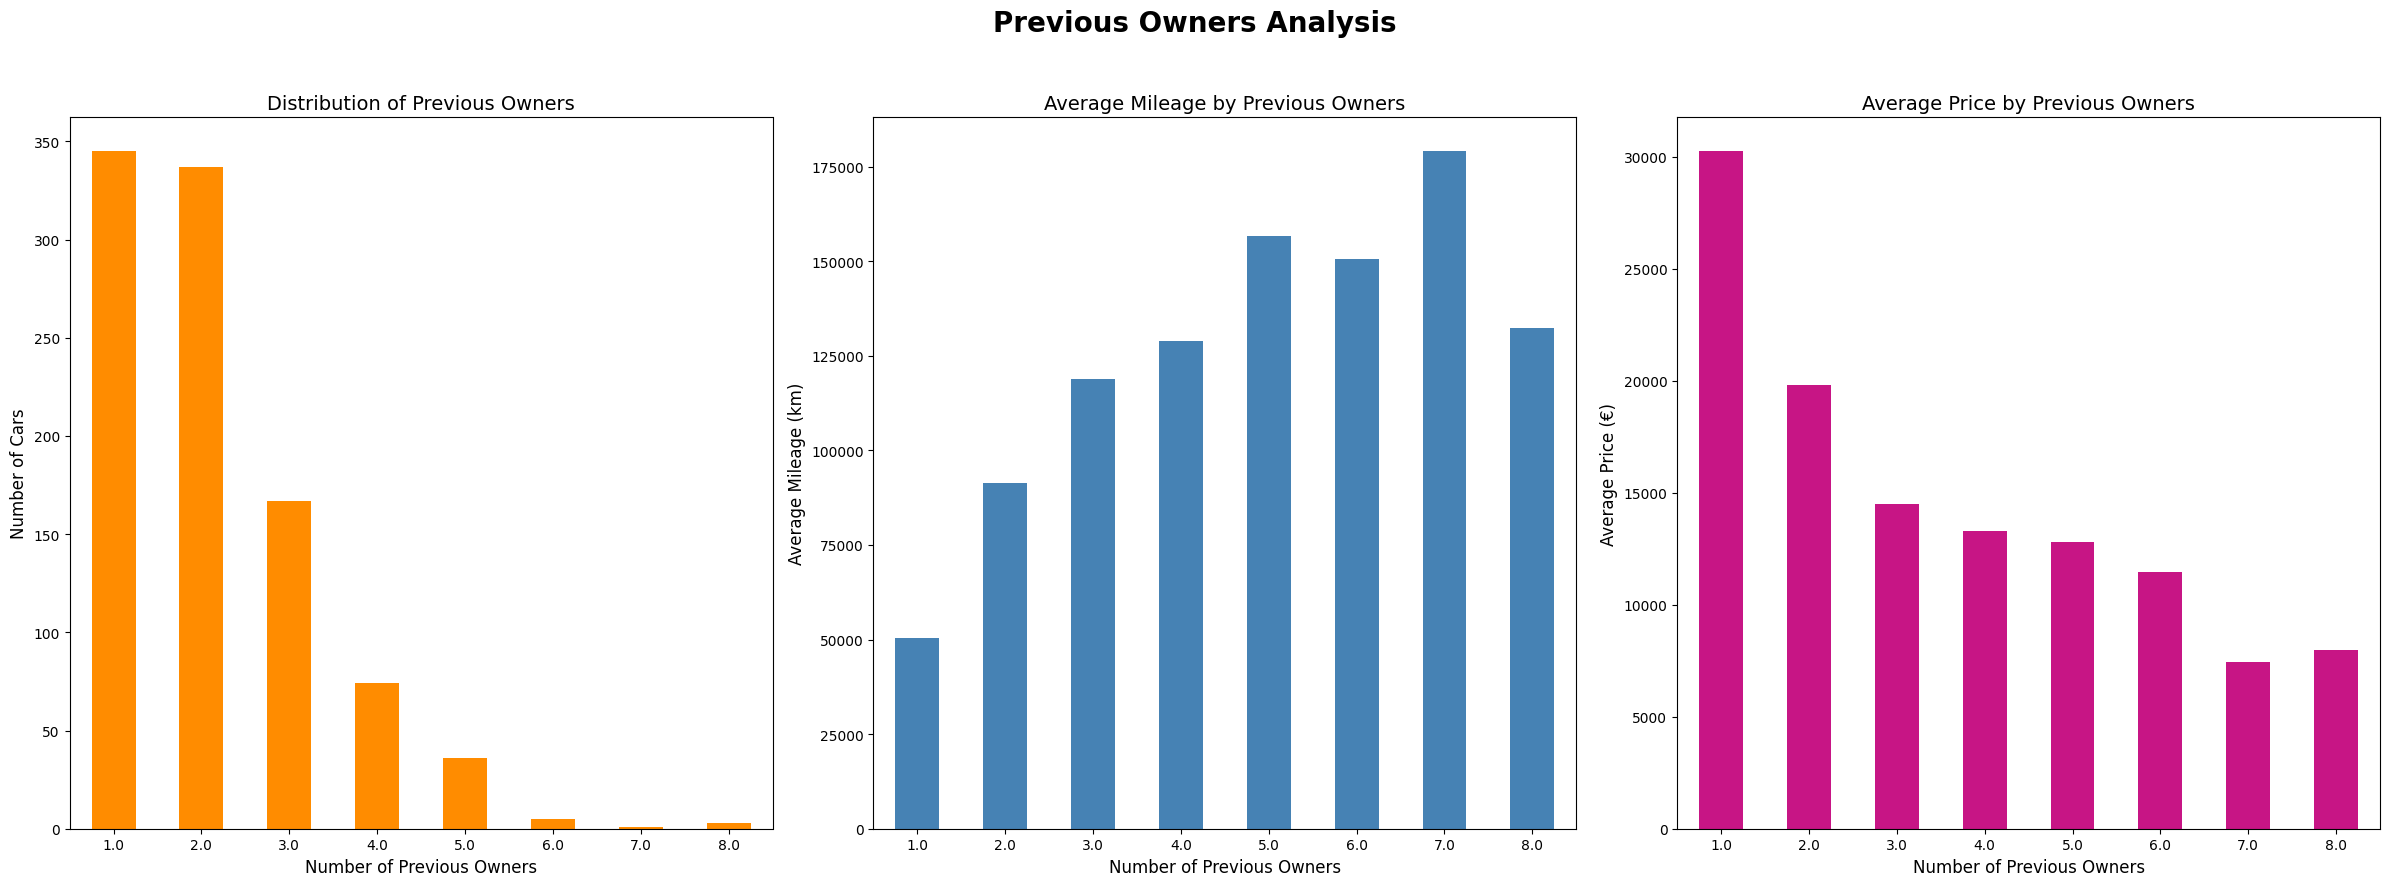

In [208]:
# Plots of Previous owners
# 1. Plots of previous owners vs Mileage, # 2. Previous owners vs Price, #3. Distribution of previous owners


fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Previous Owners Analysis', fontsize=20, fontweight='bold', y=0.98)

df["Previous Owners"].value_counts().sort_index().plot(kind="bar", ax = axes[0], color='darkorange') 
axes[0].set_title('Distribution of Previous Owners', fontsize=14)
axes[0].set_xlabel('Number of Previous Owners', fontsize=12)
axes[0].set_ylabel('Number of Cars', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

df.groupby("Previous Owners")["Mileage"].mean().plot(ax=axes[1], kind ="bar", color='steelblue')
axes[1].set_title('Average Mileage by Previous Owners', fontsize=14)
axes[1].set_xlabel('Number of Previous Owners', fontsize=12)
axes[1].set_ylabel('Average Mileage (km)', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

df.groupby("Previous Owners")["Price"].mean().plot(ax=axes[2], kind ="bar", color='mediumvioletred')
axes[2].set_title('Average Price by Previous Owners', fontsize=14)
axes[2].set_xlabel('Number of Previous Owners', fontsize=12)
axes[2].set_ylabel('Average Price (€)', fontsize=12)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.95])

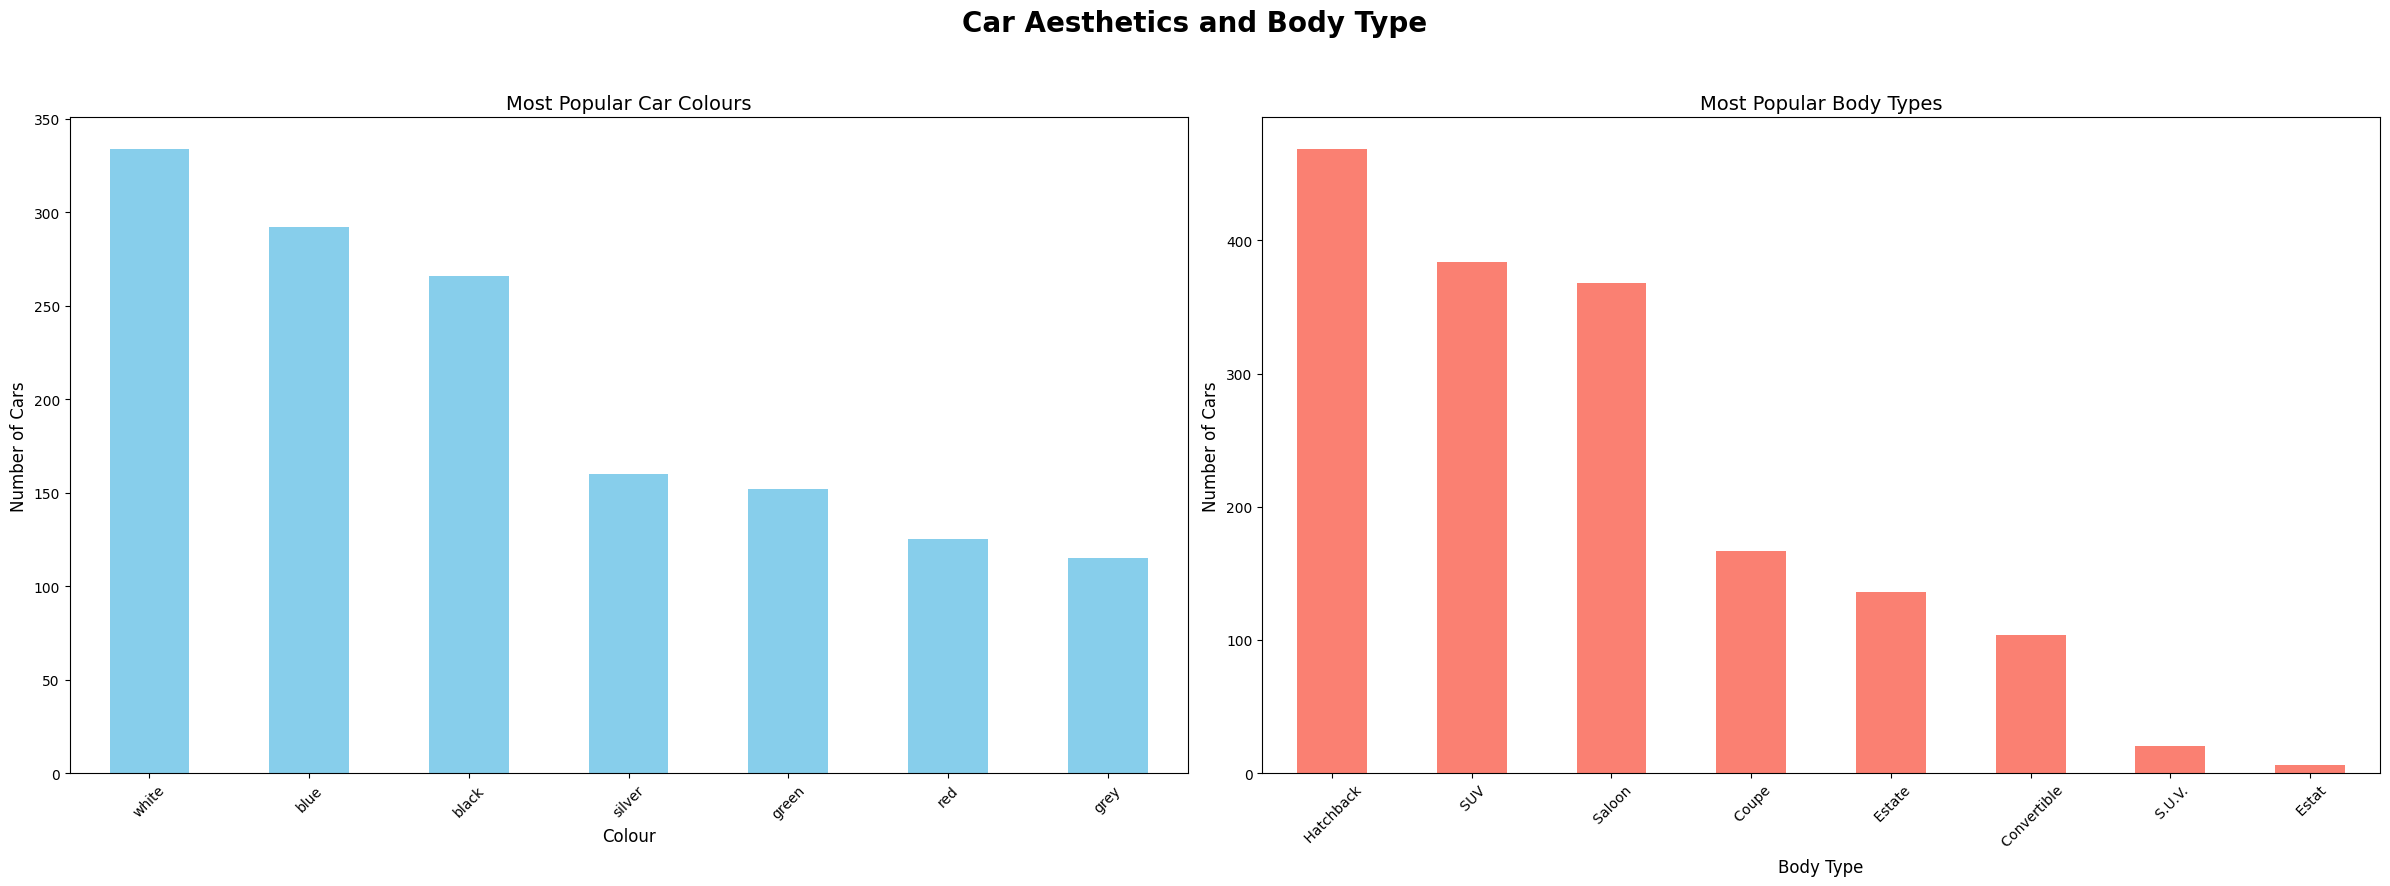

In [209]:
# Asethic plots
fig, axes = plt.subplots(1, 2, figsize=(24, 9))
fig.suptitle('Car Aesthetics and Body Type', fontsize=20, fontweight='bold', y=0.98)

# 1. Most popular Colours
df["Colour"].value_counts().plot(kind="bar", ax = axes[0], color='skyblue')
axes[0].set_title('Most Popular Car Colours', fontsize=14)
axes[0].set_xlabel('Colour', fontsize=12)
axes[0].set_ylabel('Number of Cars', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Most Popular body types
df["Body"].value_counts().plot(kind="bar", ax = axes[1], color='salmon')
axes[1].set_title('Most Popular Body Types', fontsize=14)
axes[1].set_xlabel('Body Type', fontsize=12)
axes[1].set_ylabel('Number of Cars', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])